# Flight Wi-Fi availability and customer NPS

This notebook explores how overall customer advocacy changes with the flight-level Wi-Fi status and with the customer's reported Wi-Fi experience.

**Primary outcomes**

- `LIKELIHOOD_RECOMMEND_SCL`: overall likelihood-to-recommend score (0-10)
- `NET_PROMO_CATG`: Detractor, Passive, or Promoter
- **NPS index**: `% Promoters - % Detractors` (range -100 to +100)

The analysis includes survey-level results, flight-level sensitivity checks, and cuts by delay, cabin, and fleet. Results are descriptive associations, not causal estimates.

## Important definition and analysis scope

`flight_wifi_data.csv` contains a Boolean field named `wifi_sessions`. In this notebook:

- `True` is labeled **Wi-Fi available**
- `False` is labeled **Wi-Fi unavailable**
- missing status or an unmatched flight is labeled **Unknown** and excluded from available-versus-unavailable comparisons

Confirm this interpretation with the source-table owner. If `wifi_sessions` means that at least one session was observed rather than that Wi-Fi was technically available, rename the labels to **Session recorded** / **No session recorded** before presenting the results.

The NPS file covers a wider period than the Wi-Fi flight file. Comparisons are restricted to the Wi-Fi table's date range so that earlier flights are not incorrectly treated as unavailable.

In [1]:
# %pip install seaborn

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

STATUS_ORDER = ["Wi-Fi available", "Wi-Fi unavailable", "Unknown"]
NPS_CATEGORY_ORDER = ["Detractor", "Passive", "Promoter"]
NPS_COL = "LIKELIHOOD_RECOMMEND_SCL"
WIFI_SCORE_COLS = [
    "WIFI_SATISFACTION_SCR",
    "WIFI_SPEED_SCR",
    "WIFI_PRICE_SCR",
    "WIFI_RLBLTY_SCR",
    "WIFI_EASE_USE_SCR",
    "WIFI_CNCT_EFFRT_SCR",
]

## 1. Load and prepare the data

In [3]:
flight_data = pd.read_csv("flight_wifi_data.csv")
nps_data = pd.read_csv("nps_wifi_score_all2026.csv")

print(f"Flight Wi-Fi rows: {len(flight_data):,}")
print(f"NPS survey rows:   {len(nps_data):,}")

Flight Wi-Fi rows: 625,855
NPS survey rows:   2,050,207


In [4]:
def normalize_flight_number(series):
    return series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)


def build_flight_key(df, flight_col, date_col, origin_col, destination_col):
    flight_number = normalize_flight_number(df[flight_col])
    flight_date = pd.to_datetime(df[date_col], errors="coerce").dt.strftime("%Y-%m-%d")
    origin = df[origin_col].astype("string").str.strip().str.upper()
    destination = df[destination_col].astype("string").str.strip().str.upper()
    return flight_number + " | " + flight_date + " | " + origin + "-" + destination


flight_data["departure_date"] = pd.to_datetime(flight_data["departure_date"], errors="coerce")
nps_data["SEG_DEP_DT"] = pd.to_datetime(nps_data["SEG_DEP_DT"], errors="coerce")

flight_data["UNIQUE_FLIGHT_ID"] = build_flight_key(
    flight_data, "flight_number", "departure_date", "origin", "destination"
)
nps_data["UNIQUE_FLIGHT_ID"] = build_flight_key(
    nps_data,
    "OPERAT_FLIGHT_NBR",
    "SEG_DEP_DT",
    "SEG_DEP_AIRPRT_IATA_CD",
    "SEG_ARVL_AIRPRT_IATA_CD",
)

duplicate_flight_keys = flight_data["UNIQUE_FLIGHT_ID"].duplicated().sum()
if duplicate_flight_keys:
    raise ValueError(
        f"Flight Wi-Fi data has {duplicate_flight_keys:,} duplicate flight keys; "
        "resolve these before merging to avoid duplicating survey responses."
    )

In [5]:
coverage_start = flight_data["departure_date"].min()
coverage_end = flight_data["departure_date"].max()

analysis_nps = nps_data.loc[nps_data["SEG_DEP_DT"].between(coverage_start, coverage_end)].copy()
data_combined = analysis_nps.merge(
    flight_data,
    how="left",
    on="UNIQUE_FLIGHT_ID",
    validate="many_to_one",
    indicator=True,
    suffixes=("_nps", "_flight"),
)

wifi_status = (
    data_combined["wifi_sessions"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)
data_combined["WIFI_AVAILABILITY"] = np.select(
    [
        data_combined["_merge"].eq("both") & wifi_status.eq(True),
        data_combined["_merge"].eq("both") & wifi_status.eq(False),
    ],
    ["Wi-Fi available", "Wi-Fi unavailable"],
    default="Unknown",
)
data_combined["WIFI_AVAILABILITY"] = pd.Categorical(
    data_combined["WIFI_AVAILABILITY"], categories=STATUS_ORDER, ordered=True
)

data_combined["NET_PROMO_CATG"] = (
    data_combined["NET_PROMO_CATG"].astype("string").str.strip().str.title()
)
data_combined[NPS_COL] = pd.to_numeric(data_combined[NPS_COL], errors="coerce")
for column in WIFI_SCORE_COLS:
    data_combined[column] = pd.to_numeric(data_combined[column], errors="coerce")

for column in ["scheduled_arrival_time", "actual_arrival_time"]:
    data_combined[column] = pd.to_datetime(data_combined[column], errors="coerce", utc=True)

data_combined["delay_mins"] = (
    data_combined["actual_arrival_time"] - data_combined["scheduled_arrival_time"]
).dt.total_seconds() / 60
data_combined["delay_bucket"] = pd.cut(
    data_combined["delay_mins"],
    bins=[-np.inf, 0, 30, 120, 240, np.inf],
    labels=["Early / on time", "0-30 min", "30-120 min", "2-4 hrs", ">4 hrs"],
)

comparison_data = data_combined.loc[
    data_combined["WIFI_AVAILABILITY"].isin(["Wi-Fi available", "Wi-Fi unavailable"])
].copy()
comparison_data["WIFI_AVAILABILITY"] = comparison_data["WIFI_AVAILABILITY"].cat.remove_unused_categories()

### Merge coverage and data-quality checks

In [6]:
expected_category = pd.cut(
    data_combined[NPS_COL],
    bins=[-np.inf, 6, 8, np.inf],
    labels=["Detractor", "Passive", "Promoter"],
)
category_mismatch = (
    expected_category.astype("string").ne(data_combined["NET_PROMO_CATG"])
    & data_combined[NPS_COL].notna()
    & data_combined["NET_PROMO_CATG"].notna()
).sum()

quality_summary = pd.DataFrame(
    {
        "Measure": [
            "Wi-Fi coverage start",
            "Wi-Fi coverage end",
            "NPS responses in shared period",
            "Matched responses",
            "Match rate",
            "Unique matched flights",
            "Duplicate survey response IDs",
            "NPS score/category mismatches",
        ],
        "Value": [
            coverage_start.date(),
            coverage_end.date(),
            f"{len(data_combined):,}",
            f"{data_combined['_merge'].eq('both').sum():,}",
            f"{data_combined['_merge'].eq('both').mean():.2%}",
            f"{data_combined.loc[data_combined['_merge'].eq('both'), 'UNIQUE_FLIGHT_ID'].nunique():,}",
            f"{analysis_nps['SURVEY_RESPNS_ID'].duplicated().sum():,}",
            f"{category_mismatch:,}",
        ],
    }
)
display(quality_summary)

status_counts = (
    data_combined.groupby("WIFI_AVAILABILITY", observed=False)
    .agg(Responses=("SURVEY_RESPNS_ID", "nunique"), Flights=("UNIQUE_FLIGHT_ID", "nunique"))
    .reset_index()
)
status_counts["Response share"] = status_counts["Responses"] / status_counts["Responses"].sum()
display(status_counts)

,Measure,Value
0,Wi-Fi coverage start,2026-05-26
1,Wi-Fi coverage end,2026-08-26
2,NPS responses in shared period,"855,086"
3,Matched responses,"855,073"
4,Match rate,100.00%
5,Unique matched flights,"363,325"
6,Duplicate survey response IDs,0
7,NPS score/category mismatches,0


,WIFI_AVAILABILITY,Responses,Flights,Response share
0,Wi-Fi available,725424,311131,0.85
1,Wi-Fi unavailable,105333,43130,0.12
2,Unknown,24329,9071,0.03


**Why these checks matter:** a many-to-one validated merge prevents flight duplicates from inflating response counts. The match rate and `Unknown` group show whether the availability comparison is based on the intended population.

## 2. Primary NPS comparison by Wi-Fi availability

In [7]:
# %pip install jinja2

In [8]:
def summarize_nps(df, group_cols):
    summary = (
        df.groupby(group_cols, observed=True)
        .agg(
            Responses=(NPS_COL, "count"),
            Flights=("UNIQUE_FLIGHT_ID", "nunique"),
            Mean_NPS=(NPS_COL, "mean"),
            Median_NPS=(NPS_COL, "median"),
            Promoter_rate=("NET_PROMO_CATG", lambda x: x.eq("Promoter").mean()),
            Passive_rate=("NET_PROMO_CATG", lambda x: x.eq("Passive").mean()),
            Detractor_rate=("NET_PROMO_CATG", lambda x: x.eq("Detractor").mean()),
        )
        .reset_index()
    )
    summary["NPS_index"] = 100 * (summary["Promoter_rate"] - summary["Detractor_rate"])
    return summary


availability_summary = summarize_nps(comparison_data, ["WIFI_AVAILABILITY"])
display(
    availability_summary.style.format(
        {
            "Responses": "{:,.0f}",
            "Flights": "{:,.0f}",
            "Mean_NPS": "{:.2f}",
            "Median_NPS": "{:.1f}",
            "Promoter_rate": "{:.1%}",
            "Passive_rate": "{:.1%}",
            "Detractor_rate": "{:.1%}",
            "NPS_index": "{:.1f}",
        }
    )
)

,WIFI_AVAILABILITY,Responses,Flights,Mean_NPS,Median_NPS,Promoter_rate,Passive_rate,Detractor_rate,NPS_index
0,Wi-Fi available,"725,424","311,131",6.74,8.0,48.7%,14.7%,36.6%,12.1
1,Wi-Fi unavailable,"105,333","43,130",6.66,8.0,45.2%,16.5%,38.3%,7.0


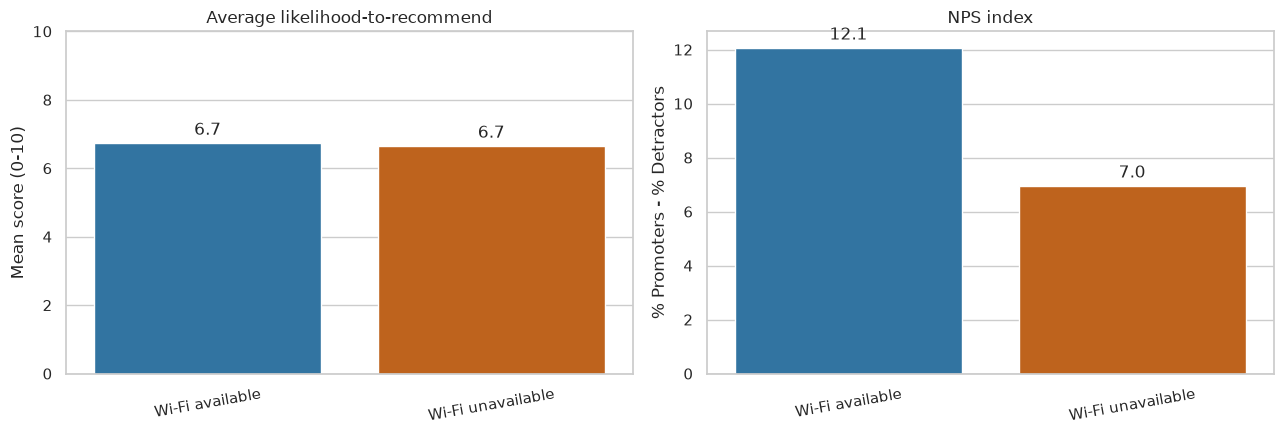

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
palette = ["#1f77b4", "#d95f02"]

sns.barplot(
    data=availability_summary,
    x="WIFI_AVAILABILITY",
    y="Mean_NPS",
    order=["Wi-Fi available", "Wi-Fi unavailable"],
    palette=palette,
    ax=axes[0],
)
axes[0].set(title="Average likelihood-to-recommend", xlabel="", ylabel="Mean score (0-10)", ylim=(0, 10))

sns.barplot(
    data=availability_summary,
    x="WIFI_AVAILABILITY",
    y="NPS_index",
    order=["Wi-Fi available", "Wi-Fi unavailable"],
    palette=palette,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="NPS index", xlabel="", ylabel="% Promoters - % Detractors")

for ax in axes:
    ax.tick_params(axis="x", rotation=10)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()
plt.show()

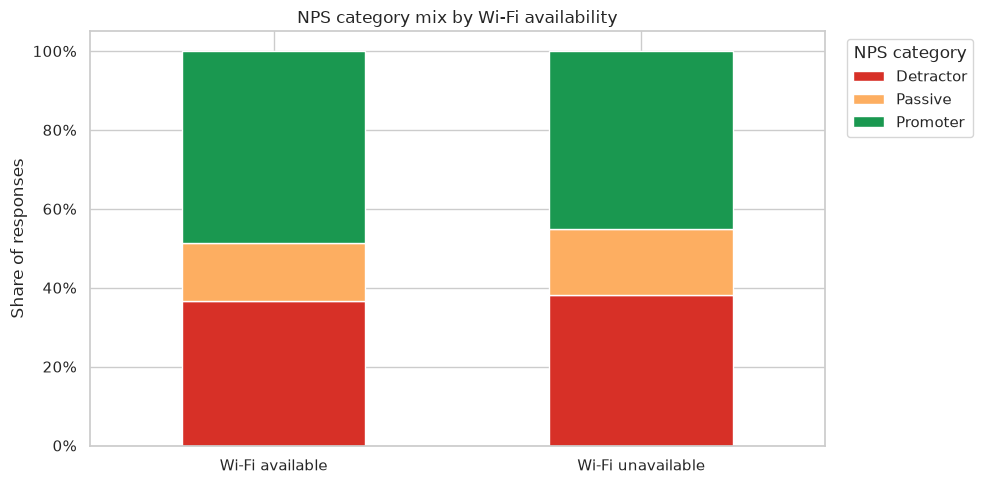

NET_PROMO_CATG,Detractor,Passive,Promoter
WIFI_AVAILABILITY,,,
Wi-Fi available,36.6%,14.7%,48.7%
Wi-Fi unavailable,38.3%,16.5%,45.2%


In [10]:
category_mix = pd.crosstab(
    comparison_data["WIFI_AVAILABILITY"],
    comparison_data["NET_PROMO_CATG"],
    normalize="index",
).reindex(
    index=["Wi-Fi available", "Wi-Fi unavailable"],
    columns=NPS_CATEGORY_ORDER,
    fill_value=0,
)

ax = category_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#d73027", "#fdae61", "#1a9850"],
)
ax.set(title="NPS category mix by Wi-Fi availability", xlabel="", ylabel="Share of responses")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="NPS category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
display(category_mix.style.format("{:.1%}"))

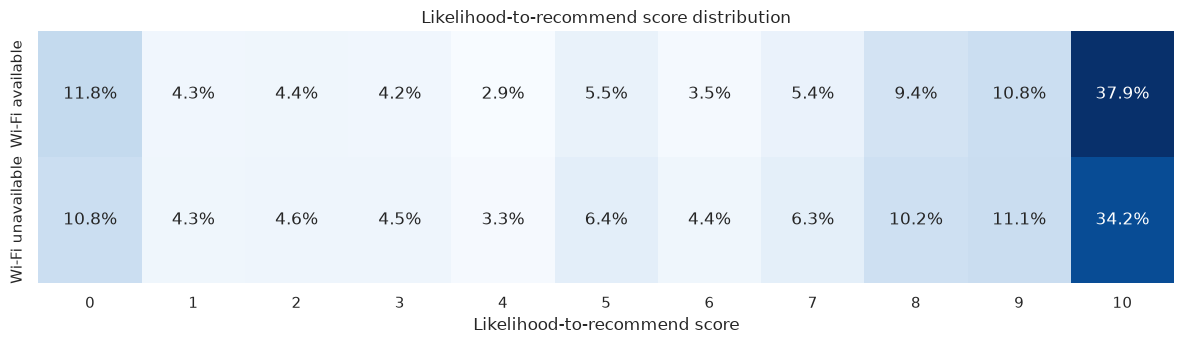

In [11]:
score_distribution = pd.crosstab(
    comparison_data["WIFI_AVAILABILITY"],
    comparison_data[NPS_COL],
    normalize="index",
).reindex(index=["Wi-Fi available", "Wi-Fi unavailable"], columns=range(11), fill_value=0)

plt.figure(figsize=(12, 3.6))
sns.heatmap(score_distribution, annot=True, fmt=".1%", cmap="Blues", cbar=False)
plt.title("Likelihood-to-recommend score distribution")
plt.xlabel("Likelihood-to-recommend score")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3. Check other factors that may influence NPS

The next cuts do not eliminate confounding, but they show whether the Wi-Fi pattern remains directionally similar among customers with comparable delay, cabin, or fleet characteristics. Small cells are suppressed from charts.

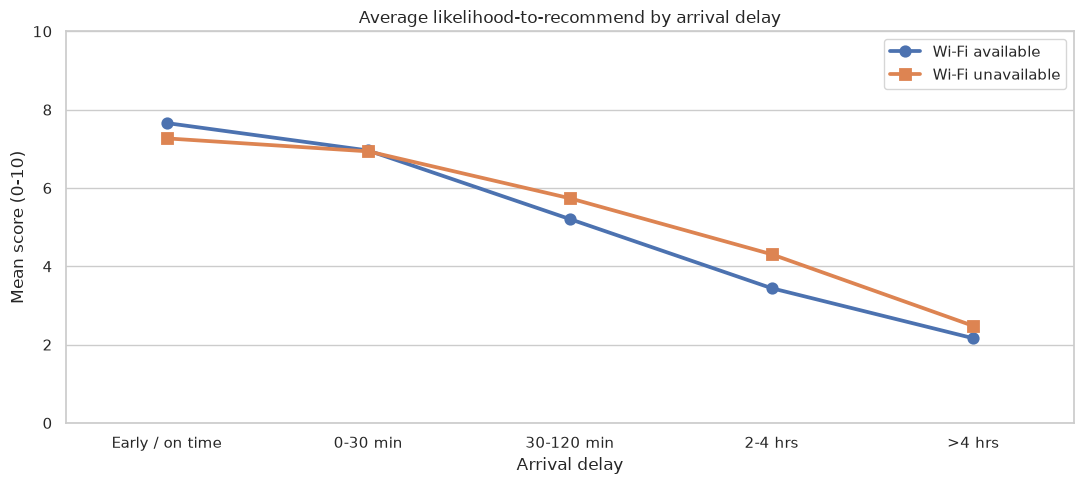

,delay_bucket,WIFI_AVAILABILITY,Responses,Mean_NPS,NPS_index
0,Early / on time,Wi-Fi available,"349,800",7.66,34.8
1,Early / on time,Wi-Fi unavailable,"39,803",7.27,20.7
2,0-30 min,Wi-Fi available,"110,856",6.96,16.0
3,0-30 min,Wi-Fi unavailable,"11,986",6.94,11.3
4,30-120 min,Wi-Fi available,"86,582",5.21,-29.4
5,30-120 min,Wi-Fi unavailable,"8,973",5.74,-19.5
6,2-4 hrs,Wi-Fi available,"31,447",3.44,-66.3
7,2-4 hrs,Wi-Fi unavailable,"2,487",4.31,-53.0
8,>4 hrs,Wi-Fi available,"14,904",2.16,-83.5
9,>4 hrs,Wi-Fi unavailable,"1,952",2.48,-78.9


In [12]:
delay_summary = summarize_nps(
    comparison_data.dropna(subset=["delay_bucket"]),
    ["delay_bucket", "WIFI_AVAILABILITY"],
)
delay_plot = delay_summary.loc[delay_summary["Responses"] >= 100].copy()

plt.figure(figsize=(11, 5))
sns.pointplot(
    data=delay_plot,
    x="delay_bucket",
    y="Mean_NPS",
    hue="WIFI_AVAILABILITY",
    order=["Early / on time", "0-30 min", "30-120 min", "2-4 hrs", ">4 hrs"],
    hue_order=["Wi-Fi available", "Wi-Fi unavailable"],
    markers=["o", "s"],
)
plt.title("Average likelihood-to-recommend by arrival delay")
plt.xlabel("Arrival delay")
plt.ylabel("Mean score (0-10)")
plt.ylim(0, 10)
plt.legend(title="")
plt.tight_layout()
plt.show()

display(
    delay_summary[
        ["delay_bucket", "WIFI_AVAILABILITY", "Responses", "Mean_NPS", "NPS_index"]
    ].style.format({"Responses": "{:,.0f}", "Mean_NPS": "{:.2f}", "NPS_index": "{:.1f}"})
)

/tmp/ipykernel_144700/849748176.py:21: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


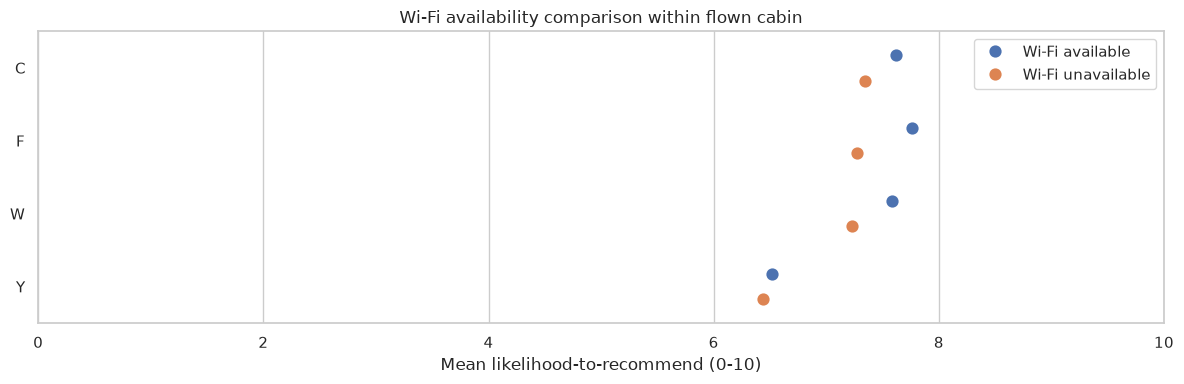

/tmp/ipykernel_144700/849748176.py:21: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


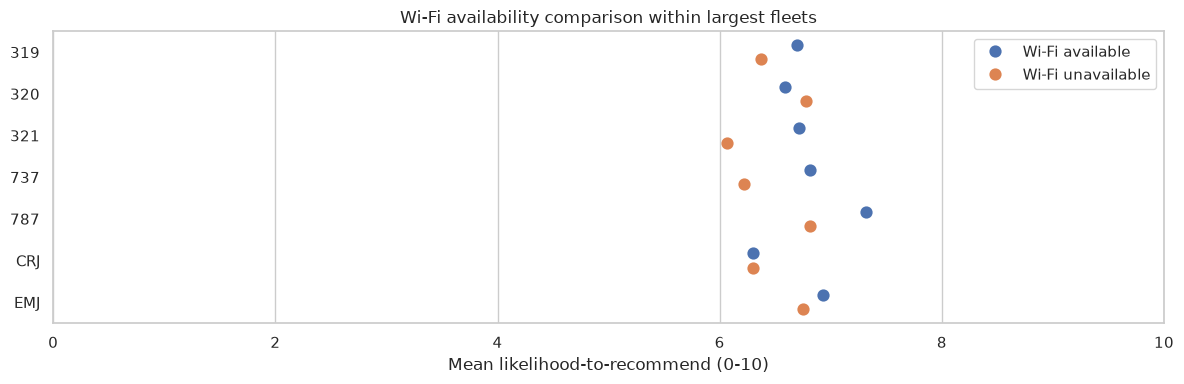

In [13]:
def plot_segment_nps(segment_col, title, top_n=None, min_responses=100):
    segment_data = comparison_data.dropna(subset=[segment_col]).copy()
    if top_n:
        top_values = segment_data[segment_col].value_counts().head(top_n).index
        segment_data = segment_data.loc[segment_data[segment_col].isin(top_values)]

    summary = summarize_nps(segment_data, [segment_col, "WIFI_AVAILABILITY"])
    complete_segments = (
        summary.loc[summary["Responses"] >= min_responses]
        .groupby(segment_col, observed=True)["WIFI_AVAILABILITY"]
        .nunique()
    )
    complete_segments = complete_segments[complete_segments.eq(2)].index
    chart_data = summary.loc[summary[segment_col].isin(complete_segments)]

    if chart_data.empty:
        print(f"No {segment_col} segments meet the comparison threshold.")
        return summary

    plt.figure(figsize=(12, max(4, 0.45 * len(complete_segments))))
    sns.pointplot(
        data=chart_data,
        y=segment_col,
        x="Mean_NPS",
        hue="WIFI_AVAILABILITY",
        hue_order=["Wi-Fi available", "Wi-Fi unavailable"],
        dodge=0.35,
        join=False,
    )
    plt.title(title)
    plt.xlabel("Mean likelihood-to-recommend (0-10)")
    plt.ylabel("")
    plt.xlim(0, 10)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()
    return summary


cabin_summary = plot_segment_nps(
    "CABIN_FLOWN_CD",
    "Wi-Fi availability comparison within flown cabin",
)
fleet_summary = plot_segment_nps(
    "FLEET_CD",
    "Wi-Fi availability comparison within largest fleets",
    top_n=10,
)

### Flight-level sensitivity check

Multiple customers can rate the same flight. Treating every survey as independent can make a result look more precise than it is. The following view gives each flight one mean NPS score and therefore tests whether the broad pattern also appears across flights.

,WIFI_AVAILABILITY,Flights,Mean_of_flight_means,Median_flight_mean
0,Wi-Fi available,"311,131",6.93,8.00
1,Wi-Fi unavailable,"43,130",6.72,7.50


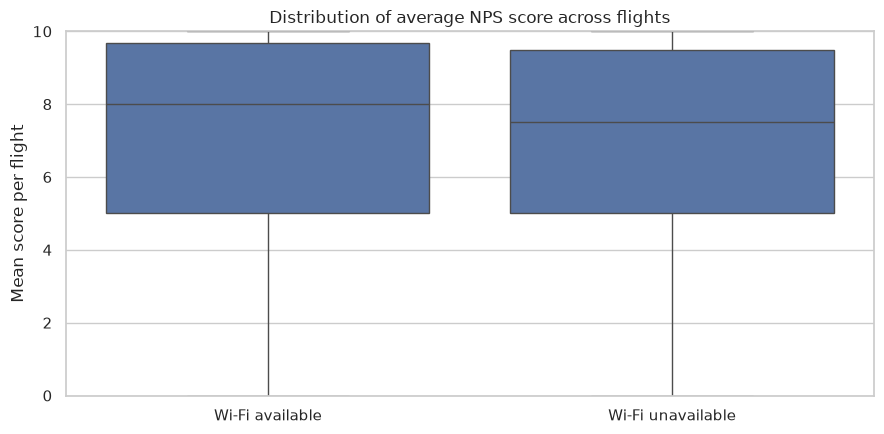

In [14]:
flight_level = (
    comparison_data.groupby(["UNIQUE_FLIGHT_ID", "WIFI_AVAILABILITY"], observed=True)
    .agg(
        Flight_mean_NPS=(NPS_COL, "mean"),
        Responses=(NPS_COL, "count"),
        Delay_mins=("delay_mins", "first"),
        Cabin=("CABIN_FLOWN_CD", lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
    )
    .reset_index()
)

flight_level_summary = (
    flight_level.groupby("WIFI_AVAILABILITY", observed=True)
    .agg(
        Flights=("UNIQUE_FLIGHT_ID", "nunique"),
        Mean_of_flight_means=("Flight_mean_NPS", "mean"),
        Median_flight_mean=("Flight_mean_NPS", "median"),
    )
    .reset_index()
)
display(
    flight_level_summary.style.format(
        {
            "Flights": "{:,.0f}",
            "Mean_of_flight_means": "{:.2f}",
            "Median_flight_mean": "{:.2f}",
        }
    )
)

plot_sample = flight_level.sample(min(100_000, len(flight_level)), random_state=42)
plt.figure(figsize=(9, 4.5))
sns.boxplot(
    data=plot_sample,
    x="WIFI_AVAILABILITY",
    y="Flight_mean_NPS",
    order=["Wi-Fi available", "Wi-Fi unavailable"],
    showfliers=False,
)
plt.title("Distribution of average NPS score across flights")
plt.xlabel("")
plt.ylabel("Mean score per flight")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

## 4. Wi-Fi satisfaction and experience attributes

Wi-Fi questions are not answered by every customer. Response coverage is shown first; conclusions about individual Wi-Fi attributes apply only to respondents who answered that question.

In [15]:
score_labels = {
    "WIFI_SATISFACTION_SCR": "Overall satisfaction",
    "WIFI_SPEED_SCR": "Speed",
    "WIFI_PRICE_SCR": "Price",
    "WIFI_RLBLTY_SCR": "Reliability",
    "WIFI_EASE_USE_SCR": "Ease of use",
    "WIFI_CNCT_EFFRT_SCR": "Connection effort",
}

score_rows = []
for column in WIFI_SCORE_COLS:
    valid = comparison_data[[column, NPS_COL, "NET_PROMO_CATG"]].dropna(subset=[column])
    score_rows.append(
        {
            "Attribute": score_labels[column],
            "Responses": len(valid),
            "Response_rate": len(valid) / len(comparison_data),
            "Mean_score": valid[column].mean(),
            "Correlation_with_NPS": valid[[column, NPS_COL]].corr(method="spearman").iloc[0, 1]
            if len(valid) > 1
            else np.nan,
            "Detractor_mean": valid.loc[valid["NET_PROMO_CATG"].eq("Detractor"), column].mean(),
            "Promoter_mean": valid.loc[valid["NET_PROMO_CATG"].eq("Promoter"), column].mean(),
        }
    )

wifi_score_summary = pd.DataFrame(score_rows).sort_values("Mean_score", na_position="last")
display(
    wifi_score_summary.style.format(
        {
            "Responses": "{:,.0f}",
            "Response_rate": "{:.1%}",
            "Mean_score": "{:.1f}",
            "Correlation_with_NPS": "{:.2f}",
            "Detractor_mean": "{:.1f}",
            "Promoter_mean": "{:.1f}",
        },
        na_rep="No responses",
    )
)

,Attribute,Responses,Response_rate,Mean_score,Correlation_with_NPS,Detractor_mean,Promoter_mean
3,Reliability,"34,826",4.2%,62.3,0.46,47.2,77.0
1,Speed,"35,148",4.2%,62.9,0.41,50.1,75.8
0,Overall satisfaction,"575,870",69.3%,64.9,0.45,49.8,78.5
5,Connection effort,"36,364",4.4%,65.7,0.37,53.3,78.1
2,Price,"20,260",2.4%,67.6,0.41,53.5,81.5
4,Ease of use,0,0.0%,No responses,No responses,No responses,No responses


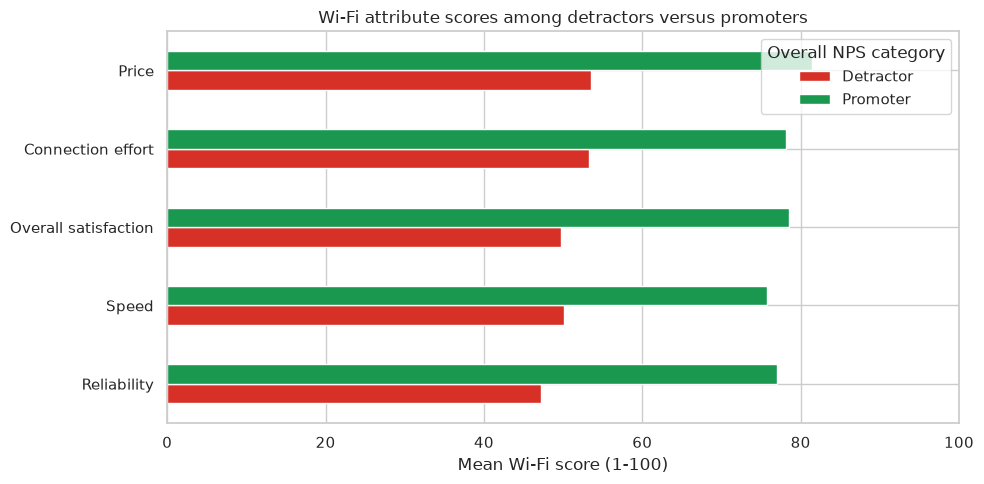

In [16]:
chart_scores = wifi_score_summary.dropna(subset=["Mean_score"]).copy()
profile = chart_scores.set_index("Attribute")[["Detractor_mean", "Promoter_mean"]]
profile.columns = ["Detractor", "Promoter"]

ax = profile.plot(kind="barh", figsize=(10, 5), color=["#d73027", "#1a9850"])
ax.set(
    title="Wi-Fi attribute scores among detractors versus promoters",
    xlabel="Mean Wi-Fi score (1-100)",
    ylabel="",
    xlim=(0, 100),
)
ax.legend(title="Overall NPS category")
plt.tight_layout()
plt.show()

### Overall Wi-Fi satisfaction and NPS

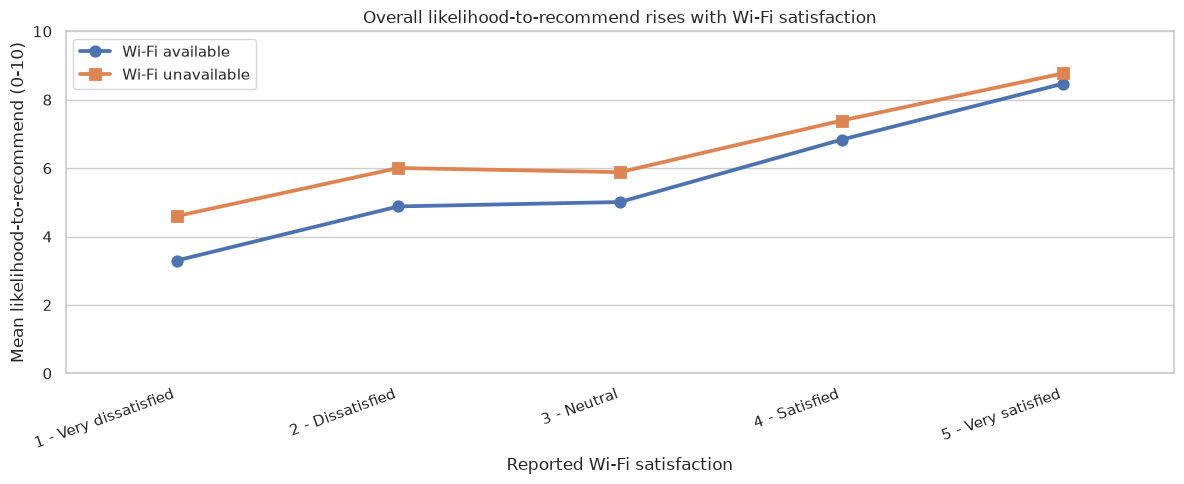

,WIFI_SATISFACTION_LEVEL,WIFI_AVAILABILITY,Responses,Mean_NPS,Promoter_rate,Detractor_rate,NPS_index
0,1 - Very dissatisfied,Wi-Fi available,"38,312",3.30,14.5%,75.5%,-61.0
1,1 - Very dissatisfied,Wi-Fi unavailable,"20,202",4.60,20.1%,64.6%,-44.5
2,2 - Dissatisfied,Wi-Fi available,"52,410",4.88,24.7%,59.6%,-34.9
3,2 - Dissatisfied,Wi-Fi unavailable,"10,329",6.00,33.8%,46.7%,-12.9
4,3 - Neutral,Wi-Fi available,"105,709",5.01,26.9%,57.9%,-30.9
5,3 - Neutral,Wi-Fi unavailable,"9,813",5.88,35.6%,47.1%,-11.5
6,4 - Satisfied,Wi-Fi available,"153,065",6.83,46.4%,35.4%,10.9
7,4 - Satisfied,Wi-Fi unavailable,"10,377",7.39,54.3%,27.9%,26.5
8,5 - Very satisfied,Wi-Fi available,"166,757",8.47,72.6%,16.2%,56.4
9,5 - Very satisfied,Wi-Fi unavailable,"8,896",8.77,78.0%,12.8%,65.2


In [17]:
satisfaction_labels = {
    1.0: "1 - Very dissatisfied",
    25.75: "2 - Dissatisfied",
    50.5: "3 - Neutral",
    75.25: "4 - Satisfied",
    100.0: "5 - Very satisfied",
}
comparison_data["WIFI_SATISFACTION_LEVEL"] = comparison_data[
    "WIFI_SATISFACTION_SCR"
].map(satisfaction_labels)
satisfaction_order = list(satisfaction_labels.values())

satisfaction_summary = summarize_nps(
    comparison_data.dropna(subset=["WIFI_SATISFACTION_LEVEL"]),
    ["WIFI_SATISFACTION_LEVEL", "WIFI_AVAILABILITY"],
)
satisfaction_summary["WIFI_SATISFACTION_LEVEL"] = pd.Categorical(
    satisfaction_summary["WIFI_SATISFACTION_LEVEL"],
    categories=satisfaction_order,
    ordered=True,
)
satisfaction_summary = satisfaction_summary.sort_values(
    ["WIFI_SATISFACTION_LEVEL", "WIFI_AVAILABILITY"]
)

plt.figure(figsize=(12, 5))
sns.pointplot(
    data=satisfaction_summary,
    x="WIFI_SATISFACTION_LEVEL",
    y="Mean_NPS",
    hue="WIFI_AVAILABILITY",
    order=satisfaction_order,
    hue_order=["Wi-Fi available", "Wi-Fi unavailable"],
    markers=["o", "s"],
)
plt.title("Overall likelihood-to-recommend rises with Wi-Fi satisfaction")
plt.xlabel("Reported Wi-Fi satisfaction")
plt.ylabel("Mean likelihood-to-recommend (0-10)")
plt.ylim(0, 10)
plt.xticks(rotation=20, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()

display(
    satisfaction_summary[
        [
            "WIFI_SATISFACTION_LEVEL",
            "WIFI_AVAILABILITY",
            "Responses",
            "Mean_NPS",
            "Promoter_rate",
            "Detractor_rate",
            "NPS_index",
        ]
    ].style.format(
        {
            "Responses": "{:,.0f}",
            "Mean_NPS": "{:.2f}",
            "Promoter_rate": "{:.1%}",
            "Detractor_rate": "{:.1%}",
            "NPS_index": "{:.1f}",
        }
    )
)

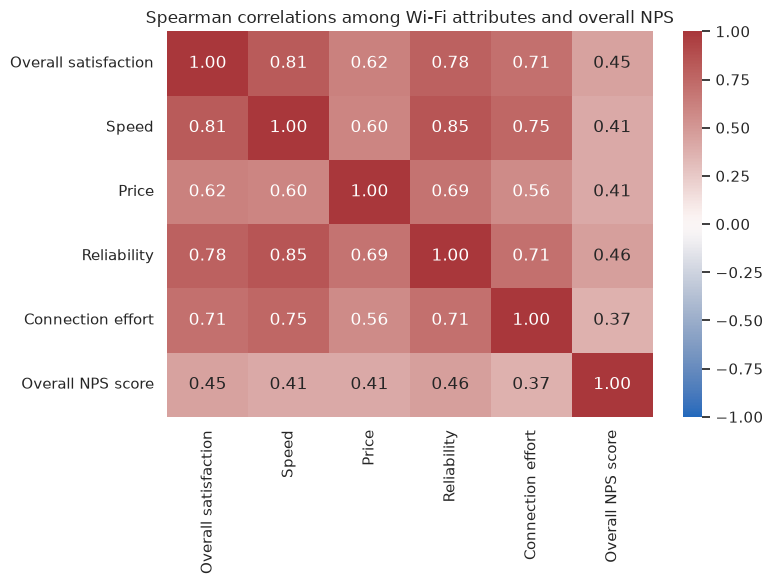

In [18]:
available_score_cols = [
    column for column in WIFI_SCORE_COLS if comparison_data[column].notna().any()
]
corr = comparison_data[available_score_cols + [NPS_COL]].corr(method="spearman")
corr = corr.rename(index=score_labels, columns=score_labels).rename(
    index={NPS_COL: "Overall NPS score"},
    columns={NPS_COL: "Overall NPS score"},
)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlations among Wi-Fi attributes and overall NPS")
plt.tight_layout()
plt.show()

## 5. Automatically generated key insights

In [19]:
availability_lookup = availability_summary.set_index("WIFI_AVAILABILITY")
survey_mean_delta = (
    availability_lookup.loc["Wi-Fi available", "Mean_NPS"]
    - availability_lookup.loc["Wi-Fi unavailable", "Mean_NPS"]
)
nps_index_delta = (
    availability_lookup.loc["Wi-Fi available", "NPS_index"]
    - availability_lookup.loc["Wi-Fi unavailable", "NPS_index"]
)

flight_lookup = flight_level_summary.set_index("WIFI_AVAILABILITY")
flight_mean_delta = (
    flight_lookup.loc["Wi-Fi available", "Mean_of_flight_means"]
    - flight_lookup.loc["Wi-Fi unavailable", "Mean_of_flight_means"]
)

valid_attributes = wifi_score_summary.dropna(subset=["Correlation_with_NPS", "Mean_score"])
strongest_attribute = valid_attributes.loc[
    valid_attributes["Correlation_with_NPS"].abs().idxmax()
]
lowest_attribute = valid_attributes.loc[valid_attributes["Mean_score"].idxmin()]

direction = "higher" if survey_mean_delta >= 0 else "lower"
flight_direction = "higher" if flight_mean_delta >= 0 else "lower"

display(
    Markdown(
        f"""
### What the descriptive results show

1. **Availability comparison:** responses on flights labeled Wi-Fi available have an average overall score that is **{abs(survey_mean_delta):.2f} points {direction}** than responses on flights labeled unavailable. The NPS index difference is **{nps_index_delta:+.1f} points**.
2. **Flight-level check:** after giving each flight one mean score, available flights are **{abs(flight_mean_delta):.2f} points {flight_direction}** on average. This indicates whether the survey-level pattern is also visible across flights rather than being driven only by flights with many responses.
3. **Strongest Wi-Fi relationship:** **{strongest_attribute['Attribute']}** has the largest observed rank correlation with overall NPS (**{strongest_attribute['Correlation_with_NPS']:.2f}**) among Wi-Fi attributes with responses.
4. **Lowest-rated Wi-Fi attribute:** **{lowest_attribute['Attribute']}** has the lowest mean score (**{lowest_attribute['Mean_score']:.1f}/100**) among measured attributes, making it a useful candidate for operational follow-up.
5. **Interpretation:** use the delay, cabin, and fleet charts to check whether the availability gap is consistent across operational contexts. Differences are associative; customer mix, route, aircraft, survey selection, and unmeasured disruption factors can still explain part of the pattern.
"""
    )
)


### What the descriptive results show

1. **Availability comparison:** responses on flights labeled Wi-Fi available have an average overall score that is **0.09 points higher** than responses on flights labeled unavailable. The NPS index difference is **+5.1 points**.
2. **Flight-level check:** after giving each flight one mean score, available flights are **0.21 points higher** on average. This indicates whether the survey-level pattern is also visible across flights rather than being driven only by flights with many responses.
3. **Strongest Wi-Fi relationship:** **Reliability** has the largest observed rank correlation with overall NPS (**0.46**) among Wi-Fi attributes with responses.
4. **Lowest-rated Wi-Fi attribute:** **Reliability** has the lowest mean score (**62.3/100**) among measured attributes, making it a useful candidate for operational follow-up.
5. **Interpretation:** use the delay, cabin, and fleet charts to check whether the availability gap is consistent across operational contexts. Differences are associative; customer mix, route, aircraft, survey selection, and unmeasured disruption factors can still explain part of the pattern.


## 6. Interpretation cautions and recommended follow-up

- **Validate the source definition of `wifi_sessions`.** A recorded session is not necessarily the same as technical availability.
- **Avoid treating unmatched flights as unavailable.** They remain `Unknown` in this notebook.
- **Wi-Fi attribute missingness is substantial and non-random.** Attribute results describe question respondents, not necessarily all passengers.
- **Survey responses on the same flight are correlated.** The flight-level analysis is the preferred sensitivity check.
- **This EDA does not establish causality.** A next-stage model could control jointly for delay, cabin, fleet, route, date, and repeated responses per flight; availability should not be interpreted as an isolated treatment effect without that design.